# Biomarker S3 — Trích biomarker neo theo xương từ mask 8-class

Input: thư mục `MASK_DIR` từ **S2** + `cohort_manifest.csv` (có nhãn KL). Output: 1 bảng CSV
`case_id, KL, <biomarker...>` — input trực tiếp cho **S4** (classifier).

**Nhãn 8-class (giống `Dataset020_KneeUnion`):**
`1 femoral_bone · 2 femoral_cart · 3 tibial_bone · 4 med_tib_cart · 5 lat_tib_cart ·
6 med_meniscus · 7 lat_meniscus · 8 patellar_cart`

**Biomarker tính cho mỗi ca:**
- Thể tích (mm³) từng cấu trúc sụn + sụn chêm (2,4,5,6,7,8).
- **Độ dày sụn chuẩn hoá theo xương** (proxy): `volume / diện tích tiếp xúc với bề mặt xương` —
  tương đương cách "chuẩn hoá theo diện tích xương dưới sụn" mà các nghiên cứu OA volumetric hay dùng,
  tránh việc thể tích thô bị nhiễu bởi kích thước khớp từng người.
- **Tỉ lệ xương lộ (denuded bone ratio)**: phần bề mặt xương KHÔNG tiếp xúc sụn / tổng bề mặt xương
  — proxy cho osteophyte/eburnation, dấu hiệu OA nặng.
- **Tỉ lệ lồi ra ngoài của sụn chêm (extrusion proxy)**: phần diện tích hình chiếu sụn chêm nằm
  ngoài "bóng" của xương chày / tổng diện tích hình chiếu sụn chêm.

**Lưu ý quan trọng:** các proxy hình học (thickness, denuded, extrusion) được tính bằng thao tác
mask thuần túy (distance transform / dilation / projection), **không dựa vào giả định cụ thể về
trục ảnh (AP/SI/ML)** — trục "lệch nhiều nhất giữa 2 cấu trúc" được tính tự động từ dữ liệu
(giống cách `merge_s6` tự dò trục có foreground nhiều nhất để chọn slice QC). Trước khi tin dùng
biomarker này cho phân tích chính thức, **nên QC trực quan vài ca** (mục 5 bên dưới) để xác nhận
hướng đo hợp lý về mặt giải phẫu.


In [3]:
!pip install -q SimpleITK scikit-image scipy pandas matplotlib

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0) Cấu hình

In [5]:
from pathlib import Path
import numpy as np, pandas as pd, SimpleITK as sitk
from scipy import ndimage as ndi

BIOM_DIR = Path("/content/drive/MyDrive/knee_biomarkers")
MASK_DIR = BIOM_DIR / "masks"
COHORT_CSV = BIOM_DIR / "cohort_manifest.csv"
OUT_CSV = BIOM_DIR / "biomarker_table.csv"

LABELS = {1:"femoral_bone", 2:"femoral_cart", 3:"tibial_bone", 4:"med_tib_cart",
          5:"lat_tib_cart", 6:"med_meniscus", 7:"lat_meniscus", 8:"patellar_cart"}

cohort = pd.read_csv(COHORT_CSV)

# >>> FIX duplicate: dedupe ngay khi load, phong truong hop cohort_manifest.csv
# van con sot case_id trung (vd chua chay ban S1 da patch, hoac file cu).
n_before = len(cohort)
cohort = cohort.drop_duplicates(subset=["case_id"]).reset_index(drop=True)
if len(cohort) < n_before:
    print(f"CANH BAO: cohort_manifest.csv co {n_before - len(cohort)} dong trung case_id, da loai.")

mask_files = {p.stem.replace(".nii",""): p for p in MASK_DIR.glob("*.nii.gz")}
cohort = cohort[cohort["case_id"].isin(mask_files)].reset_index(drop=True)
assert not cohort["case_id"].duplicated().any(), "Van con case_id trung trong cohort!"
print("ca co du mask de trich bien so:", len(cohort))


ca co du mask de trich bien so: 559


## 1) Hàm tiện ích: load mask + spacing

In [6]:
def load_mask(case_id):
    img = sitk.ReadImage(str(mask_files[case_id]))
    arr = sitk.GetArrayFromImage(img).astype(np.uint8)   # (z,y,x)
    spacing = np.array(img.GetSpacing())[::-1]            # khop thu tu (z,y,x)
    return arr, spacing

def voxel_vol_mm3(spacing):
    return float(spacing[0] * spacing[1] * spacing[2])

def label_volume_mm3(arr, spacing, lab):
    return int((arr == lab).sum()) * voxel_vol_mm3(spacing)


## 2) Hàm biomarker: độ dày chuẩn hoá theo xương + tỉ lệ xương lộ

`contact_area_mm2`: bề mặt xương (voxel biên) giao với sụn đã dilate 1 voxel — xấp xỉ diện tích
tiếp xúc bằng cạnh voxel nhỏ nhất (in-plane), đủ dùng làm feature tương đối cho ML (không phải
phép đo lâm sàng chính xác tuyệt đối — nếu cần độ chính xác cao hơn, thay bằng marching-cubes
surface area qua `skimage.measure.marching_cubes`).

In [7]:
def bone_surface(bone_bin):
    er = ndi.binary_erosion(bone_bin)
    return bone_bin & ~er

def contact_and_surface_area(bone_bin, cart_bin, spacing):
    surf = bone_surface(bone_bin)
    cart_dil = ndi.binary_dilation(cart_bin)
    contact = surf & cart_dil
    s = sorted(spacing)
    face_area = s[0] * s[1]           # 2 canh nho nhat ~ in-plane
    return float(contact.sum()) * face_area, float(surf.sum()) * face_area

def cartilage_thickness_proxy(vol_mm3, contact_mm2):
    return vol_mm3 / contact_mm2 if contact_mm2 > 0 else np.nan

def denuded_ratio(bone_bin, cart_bin):
    surf = bone_surface(bone_bin)
    if surf.sum() == 0:
        return np.nan
    contact = surf & ndi.binary_dilation(cart_bin)
    return 1.0 - contact.sum() / surf.sum()


## 3) Hàm biomarker: extrusion proxy cho sụn chêm

Chiếu (project) khối xương chày và sụn chêm dọc theo trục có mức tách biệt (centroid) lớn nhất
giữa 2 cấu trúc, rồi so sánh 2 "bóng" 2D — phần sụn chêm nằm ngoài bóng xương chày càng lớn
→ extrusion càng nhiều. Đây là proxy hình học, không phải phép đo coronal chuẩn lâm sàng.

In [8]:
def split_axis_by_centroids(mask_a, mask_b):
    ca = np.array(ndi.center_of_mass(mask_a)) if mask_a.sum() else np.zeros(3)
    cb = np.array(ndi.center_of_mass(mask_b)) if mask_b.sum() else np.zeros(3)
    return int(np.argmax(np.abs(ca - cb)))

def meniscus_extrusion_ratio(arr, meniscus_lab, tibial_bone_lab=3):
    men = arr == meniscus_lab
    tib = arr == tibial_bone_lab
    if men.sum() == 0 or tib.sum() == 0:
        return np.nan
    axis = split_axis_by_centroids(tib, men)
    tib_foot = tib.any(axis=axis)
    men_foot = men.any(axis=axis)
    if men_foot.sum() == 0:
        return np.nan
    outside = men_foot & ~tib_foot
    return float(outside.sum()) / float(men_foot.sum())


### Checkpoint thay cho mục 4)


In [9]:
!pip install -q tqdm

In [10]:
from tqdm.auto import tqdm
import pandas as pd

CHECKPOINT_CSV = BIOM_DIR / "biomarker_table_partial.csv"

# Resume: neu da co checkpoint tu lan chay truoc, chi xu ly tiep case con thieu
if CHECKPOINT_CSV.exists():
    biom_done = pd.read_csv(CHECKPOINT_CSV)
    done_ids = set(biom_done["case_id"])
    print(f"tim thay checkpoint: {len(biom_done)} ca da xong, tiep tuc phan con lai")
else:
    biom_done = pd.DataFrame()
    done_ids = set()

todo = cohort[~cohort["case_id"].isin(done_ids)]
print(f"con lai can trich: {len(todo)}/{len(cohort)} ca")

rows = []
errors = []
SAVE_EVERY = 20   # ghi checkpoint moi 20 ca, khong cho doi den het moi luu

pbar = tqdm(todo["case_id"].tolist(), desc="Trich bien so", unit="ca")
for i, case_id in enumerate(pbar):
    try:
        arr, spacing = load_mask(case_id)
        row = {"case_id": case_id}

        for lab, name in LABELS.items():
            row[f"vol_{name}_mm3"] = label_volume_mm3(arr, spacing, lab)

        fem_bone, tib_bone = arr == 1, arr == 3
        fem_cart, med_tib, lat_tib = arr == 2, arr == 4, arr == 5

        ct, sa = contact_and_surface_area(fem_bone, fem_cart, spacing)
        row["thickness_femoral_mm"] = cartilage_thickness_proxy(row["vol_femoral_cart_mm3"], ct)
        row["denuded_ratio_femoral"] = denuded_ratio(fem_bone, fem_cart)

        ct, sa = contact_and_surface_area(tib_bone, med_tib, spacing)
        row["thickness_med_tib_mm"] = cartilage_thickness_proxy(row["vol_med_tib_cart_mm3"], ct)
        ct, sa = contact_and_surface_area(tib_bone, lat_tib, spacing)
        row["thickness_lat_tib_mm"] = cartilage_thickness_proxy(row["vol_lat_tib_cart_mm3"], ct)
        row["denuded_ratio_tibial"] = denuded_ratio(tib_bone, (med_tib | lat_tib))

        row["extrusion_med_meniscus"] = meniscus_extrusion_ratio(arr, 6, tibial_bone_lab=3)
        row["extrusion_lat_meniscus"] = meniscus_extrusion_ratio(arr, 7, tibial_bone_lab=3)

        rows.append(row)
    except Exception as e:
        errors.append((case_id, str(e)))
        pbar.write(f"LOI o case {case_id}: {e} -> bo qua, tiep tuc")
        continue

    # cap nhat thanh progress: hien them ca vua xong + so loi gap
    pbar.set_postfix(xong=len(rows), loi=len(errors))

    if (i + 1) % SAVE_EVERY == 0:
        pd.concat([biom_done, pd.DataFrame(rows)], ignore_index=True) \
            .to_csv(CHECKPOINT_CSV, index=False)

# luu lan cuoi + gop full
biom = pd.concat([biom_done, pd.DataFrame(rows)], ignore_index=True)
biom.to_csv(CHECKPOINT_CSV, index=False)

print(f"\nxong: {len(biom)}/{len(cohort)} ca | loi: {len(errors)} ca")
if errors:
    print("cac case bi loi (kiem tra lai mask):")
    for cid, msg in errors:
        print(f"  - {cid}: {msg}")
biom.head()

con lai can trich: 559/559 ca


Trich bien so:   0%|          | 0/559 [00:00<?, ?ca/s]


xong: 559/559 ca | loi: 0 ca


,case_id,vol_femoral_bone_mm3,vol_femoral_cart_mm3,vol_tibial_bone_mm3,vol_med_tib_cart_mm3,vol_lat_tib_cart_mm3,vol_med_meniscus_mm3,vol_lat_meniscus_mm3,vol_patellar_cart_mm3,thickness_femoral_mm,denuded_ratio_femoral,thickness_med_tib_mm,thickness_lat_tib_mm,denuded_ratio_tibial,extrusion_med_meniscus,extrusion_lat_meniscus
0,9001104_V00_R,194917.126443,11473.063852,111374.050668,1629.585022,1705.044280,1990.133267,1998.786425,2370.034811,4.010356,0.784213,2.540365,3.194894,0.847271,0.076190,0.000000
1,9002430_V00_R,223863.800434,19586.190241,148588.584397,2844.190645,3282.338176,3197.202268,2967.940107,3569.846325,6.354122,0.788014,3.771167,4.836251,0.854295,0.298307,0.000000
2,9002817_V00_R,174680.274557,15132.884410,108195.736476,2153.984998,2068.663001,2385.201098,1956.544127,2443.167952,5.499937,0.779231,3.259252,3.545933,0.842466,0.215972,0.000000
3,9003406_V00_L,216636.738802,18304.220250,132492.315077,2341.470086,2757.752111,2693.923441,3373.335901,2964.218319,4.948345,0.746949,3.362378,4.427507,0.856384,0.107921,0.000000
4,9003430_V00_R,215831.622941,16548.838782,118159.149935,2448.099321,3189.293468,3185.199501,2501.786118,3617.671305,5.808047,0.801257,3.807670,5.556716,0.846308,0.306676,0.002132


## 4) Vòng lặp trích biomarker cho toàn cohort

In [11]:
rows = []
for i, case_id in enumerate(cohort["case_id"]):
    arr, spacing = load_mask(case_id)
    row = {"case_id": case_id}

    for lab, name in LABELS.items():
        row[f"vol_{name}_mm3"] = label_volume_mm3(arr, spacing, lab)

    fem_bone, tib_bone = arr == 1, arr == 3
    fem_cart, med_tib, lat_tib = arr == 2, arr == 4, arr == 5

    ct, sa = contact_and_surface_area(fem_bone, fem_cart, spacing)
    row["thickness_femoral_mm"] = cartilage_thickness_proxy(row["vol_femoral_cart_mm3"], ct)
    row["denuded_ratio_femoral"] = denuded_ratio(fem_bone, fem_cart)

    ct, sa = contact_and_surface_area(tib_bone, med_tib, spacing)
    row["thickness_med_tib_mm"] = cartilage_thickness_proxy(row["vol_med_tib_cart_mm3"], ct)
    ct, sa = contact_and_surface_area(tib_bone, lat_tib, spacing)
    row["thickness_lat_tib_mm"] = cartilage_thickness_proxy(row["vol_lat_tib_cart_mm3"], ct)
    row["denuded_ratio_tibial"] = denuded_ratio(tib_bone, (med_tib | lat_tib))

    row["extrusion_med_meniscus"] = meniscus_extrusion_ratio(arr, 6, tibial_bone_lab=3)
    row["extrusion_lat_meniscus"] = meniscus_extrusion_ratio(arr, 7, tibial_bone_lab=3)

    rows.append(row)
    if (i + 1) % 50 == 0:
        print(f"...{i+1}/{len(cohort)}")

biom = pd.DataFrame(rows)
print("xong, so ca:", len(biom))
biom.head()


...50/559
...100/559
...150/559
...200/559
...250/559
...300/559
...350/559
...400/559
...450/559
...500/559
...550/559
xong, so ca: 559


,case_id,vol_femoral_bone_mm3,vol_femoral_cart_mm3,vol_tibial_bone_mm3,vol_med_tib_cart_mm3,vol_lat_tib_cart_mm3,vol_med_meniscus_mm3,vol_lat_meniscus_mm3,vol_patellar_cart_mm3,thickness_femoral_mm,denuded_ratio_femoral,thickness_med_tib_mm,thickness_lat_tib_mm,denuded_ratio_tibial,extrusion_med_meniscus,extrusion_lat_meniscus
0,9001104_V00_R,194917.126443,11473.063852,111374.050668,1629.585022,1705.044280,1990.133267,1998.786425,2370.034811,4.010356,0.784213,2.540365,3.194894,0.847271,0.076190,0.000000
1,9002430_V00_R,223863.800434,19586.190241,148588.584397,2844.190645,3282.338176,3197.202268,2967.940107,3569.846325,6.354122,0.788014,3.771167,4.836251,0.854295,0.298307,0.000000
2,9002817_V00_R,174680.274557,15132.884410,108195.736476,2153.984998,2068.663001,2385.201098,1956.544127,2443.167952,5.499937,0.779231,3.259252,3.545933,0.842466,0.215972,0.000000
3,9003406_V00_L,216636.738802,18304.220250,132492.315077,2341.470086,2757.752111,2693.923441,3373.335901,2964.218319,4.948345,0.746949,3.362378,4.427507,0.856384,0.107921,0.000000
4,9003430_V00_R,215831.622941,16548.838782,118159.149935,2448.099321,3189.293468,3185.199501,2501.786118,3617.671305,5.808047,0.801257,3.807670,5.556716,0.846308,0.306676,0.002132


## 5) QC nhanh: vẽ overlay 1 ca để kiểm tra hướng đo hợp lý (khuyến nghị làm trước khi tin số liệu)

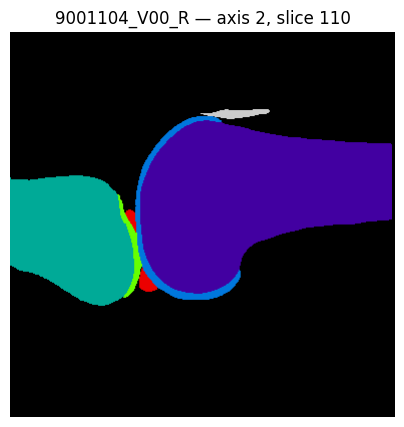

Kiem tra: xuong dui/chay/sun/sun chem co nam dung vi tri giai phau khong.


In [12]:
import matplotlib.pyplot as plt

def best_slice(lab):
    cands = []
    for ax in range(3):
        other = tuple(i for i in range(3) if i != ax)
        counts = (lab > 0).sum(axis=other)
        cands.append((int(counts.max()), ax, int(counts.argmax())))
    cands.sort(reverse=True)
    return cands[0][1], cands[0][2]

qc_case = cohort["case_id"].iloc[0]
arr, spacing = load_mask(qc_case)
ax, z = best_slice(arr)
sl = np.take(arr, z, axis=ax)
plt.figure(figsize=(5,5))
plt.imshow(sl.T, cmap="nipy_spectral", origin="lower", vmin=0, vmax=8)
plt.title(f"{qc_case} — axis {ax}, slice {z}")
plt.axis("off"); plt.show()
print("Kiem tra: xuong dui/chay/sun/sun chem co nam dung vi tri giai phau khong.")


## 6) Ghép nhãn KL grade + lưu bảng cuối

In [13]:
# >>> FIX duplicate: bien = cohort da dedup o cell 4, nhung dedupe them lan
# nua o ca hai phia truoc merge de tuyet doi an toan (vong lap cell 4 co the
# tao ra nhieu dong / case_id neu ham bi goi lai/rows bi append nham).
biom_dedup = biom.drop_duplicates(subset=["case_id"], keep="first")
if len(biom_dedup) < len(biom):
    print(f"CANH BAO: biom co {len(biom) - len(biom_dedup)} dong trung case_id, da loai truoc merge.")

final = cohort.merge(biom_dedup, on="case_id", how="inner")
assert not final["case_id"].duplicated().any(), (
    "Van con case_id trung sau merge cohort x biom -> kiem tra lai nguon du lieu dau vao!"
)
final.to_csv(OUT_CSV, index=False)
print("da luu:", OUT_CSV, "| so ca:", len(final), "| so cot:", final.shape[1])
final.describe(include="all").T.head(20)


da luu: /content/drive/MyDrive/knee_biomarkers/biomarker_table.csv | so ca: 559 | so cot: 24


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
subject,559.0,NaN,NaN,NaN,9397415.543828,267079.297318,9001104.0,9189428.0,9369286.0,9556959.0,9996098.0
side,559,2,R,516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visit,559,1,V00,559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KL,559.0,NaN,NaN,NaN,2.123435,1.305134,0.0,1.0,2.0,3.0,4.0
case_id,559,559,9996098_V00_R,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dess_path,559,559,/content/drive/MyDrive/nnUNet_raw/Dataset001_K...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mask_status,559,2,need_inference,492,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_dataset,559,3,partial_gt_oaizib_ai_meniscus_patella,471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
partial_gt_path,471,471,/content/drive/MyDrive/nnUNet_raw/Dataset001_K...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vol_femoral_bone_mm3,559.0,NaN,NaN,NaN,184645.090344,37311.132979,106779.689059,154743.677944,181661.977292,210935.470821,313573.414255


## Ghi chú
- `biomarker_table.csv` = input duy nhất cho **S4** (`case_id, KL, ...biomarkers`).
- Nếu về sau muốn thêm biomarker viêm (BML/effusion volume) như bản gốc từng bàn: cần thêm 1
  segmentation dịch riêng (không có trong `Dataset020` hiện tại) — không suy ra được từ mask này.
- `thickness_*` và `extrusion_*` là **proxy hình học**, phù hợp làm feature cho classifier ở S4,
  nhưng nếu cần công bố như phép đo lâm sàng chuẩn, nên đối chiếu với phương pháp
  chuẩn (vd Eckstein / Wirth cartilage thickness mapping) trên vài ca mẫu.


## 7) [MỚI] Gắn `source_dataset` vào bảng biomarker cuối

Để S4/S5 làm được sensitivity analysis (so kết quả trên tập tin cậy cao vs tập đầy đủ), bảng
`biomarker_table.csv` cần giữ lại cột `source_dataset` (từ S1/S2 — xem `mask_provenance.csv`).
Không xoá cột này khi lọc `FEATURE_COLS` ở S4 (nó không bắt đầu bằng `vol_/thickness_/denuded_/
extrusion_` nên tự động không bị coi là feature — chỉ dùng để nhóm/so sánh).

In [14]:
# source_dataset da co san trong 'cohort' (doc tu cohort_manifest.csv da duoc S1/S2 cap nhat) ->
# 'final' (ket qua merge cohort x biom o cell truoc) da tu dong co cot nay roi. Kiem tra lai:
assert "source_dataset" in final.columns, (
    "Thieu cot source_dataset trong 'final' -> kiem tra da chay ban S1/S2 da patch "
    "(co section '[MỚI] source_dataset') truoc khi chay S3 nay chua."
)
print(final["source_dataset"].value_counts())


source_dataset
partial_gt_oaizib_ai_meniscus_patella    471
gt_real_imorphics                         67
ai_full_8class                            21
Name: count, dtype: int64
